<a href="https://colab.research.google.com/github/tylerdurdenhere/db_and_analytics/blob/main/r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install & Load Libraries
install.packages(c("ggplot2", "dplyr", "readr", "corrplot",
                   "gridExtra", "scales", "IRdisplay"))

library(ggplot2)
library(dplyr)
library(readr)
library(corrplot)
library(gridExtra)
library(scales)
library(IRdisplay)

cat("All libraries loaded successfully.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




All libraries loaded successfully.


In [2]:
# Load Cleaned Datasets

orders     <- read_csv("/content/orders_clean.csv",     show_col_types=FALSE)
deliveries <- read_csv("/content/deliveries_clean.csv", show_col_types=FALSE)
customers  <- read_csv("/content/customers_clean.csv",  show_col_types=FALSE)
drivers    <- read_csv("/content/drivers_clean.csv",    show_col_types=FALSE)
vehicles   <- read_csv("/content/vehicles_clean.csv",   show_col_types=FALSE)
hubs       <- read_csv("/content/hubs_clean.csv",       show_col_types=FALSE)
incidents  <- read_csv("/content/incidents_clean.csv",  show_col_types=FALSE)
complaints <- read_csv("/content/complaints_clean.csv", show_col_types=FALSE)
app_events <- read_csv("/content/app_events_clean.csv", show_col_types=FALSE)

cat("All datasets loaded.\n")

All datasets loaded.


In [3]:
# Build Master Analytical Dataset
# Join all key tables into one analytical flat file

master <- deliveries %>%
  left_join(orders,     by="order_id") %>%
  left_join(customers,  by="customer_id") %>%
  left_join(drivers,    by="driver_id") %>%
  left_join(vehicles,   by="vehicle_id") %>%
  left_join(hubs,       by="hub_id") %>%
  mutate(
    is_delayed   = ifelse(delivery_status %in% c("Delayed","Failed"), 1, 0),
    is_failed    = ifelse(delivery_status == "Failed", 1, 0),
    high_override = ifelse(manual_route_override_count > 1, 1, 0),
    low_battery  = ifelse(battery_health_pct < 60, 1, 0),
    dispatch_time         = as.POSIXct(dispatch_time),
    delivery_completed_at = as.POSIXct(delivery_completed_at),
    delivery_duration_hrs = as.numeric(
      difftime(delivery_completed_at, dispatch_time, units="hours"))
  )

cat(sprintf("Master dataset: %d rows, %d columns\n", nrow(master), ncol(master)))
cat("Key columns:\n")
print(names(master))

Master dataset: 950 rows, 58 columns
Key columns:
 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"           "delivery_duration_hrs"        
[15] "is_delayed"                    "high_override"                
[17] "customer_id"                   "service_type"                 
[19] "order_created_at"              "promised_window_hours"        
[21] "pickup_zone"                   "dropoff_zone"                 
[23] "priority_level"                "order_value"                  
[25] "booking_channel"               "special_handling_flag"        
[27] "value_band"                    "order_hour"    

In [4]:
# Cell 4: Descriptive Statistics
cat("═══════════════════════════════════════════════\n")
cat("DESCRIPTIVE STATISTICS — KEY NUMERIC VARIABLES\n")
cat("═══════════════════════════════════════════════\n")

numeric_vars <- master %>%
  select(order_value, delivery_duration_hrs, manual_route_override_count,
         customer_rating_post_delivery, driver_rating, battery_health_pct,
         loyalty_score, is_delayed) %>%
  summary()

print(numeric_vars)

cat("\n═══════════════════════════\n")
cat("DELIVERY STATUS BREAKDOWN\n")
cat("═══════════════════════════\n")
status_summary <- master %>%
  group_by(delivery_status) %>%
  summarise(
    count         = n(),
    pct           = round(n() / nrow(master) * 100, 1),
    avg_rating    = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm=TRUE), 2)
  )
print(status_summary)

cat("\n═══════════════════════════\n")
cat("ZONE-LEVEL SUMMARY\n")
cat("═══════════════════════════\n")
zone_summary <- master %>%
  group_by(pickup_zone) %>%
  summarise(
    total         = n(),
    failure_rate  = round(mean(is_delayed) * 100, 1),
    avg_rating    = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm=TRUE), 2),
    avg_value     = round(mean(order_value, na.rm=TRUE), 2)
  ) %>%
  arrange(desc(failure_rate))
print(zone_summary)

═══════════════════════════════════════════════
DESCRIPTIVE STATISTICS — KEY NUMERIC VARIABLES
═══════════════════════════════════════════════
  order_value     delivery_duration_hrs manual_route_override_count
 Min.   :  2.04   Min.   :-2.214        Min.   :0.0000             
 1st Qu.: 48.61   1st Qu.: 2.946        1st Qu.:0.0000             
 Median : 77.17   Median : 7.074        Median :1.0000             
 Mean   : 91.86   Mean   : 9.545        Mean   :0.9695             
 3rd Qu.:122.82   3rd Qu.:14.644        3rd Qu.:2.0000             
 Max.   :510.06   Max.   :43.457        Max.   :7.0000             
                  NAs    :19                                       
 customer_rating_post_delivery driver_rating   battery_health_pct
 Min.   :1.000                 Min.   :3.150   Min.   : 42.00    
 1st Qu.:3.373                 1st Qu.:3.905   1st Qu.: 68.60    
 Median :4.040                 Median :4.170   Median : 78.05    
 Mean   :3.867                 Mean   :4.164   Me

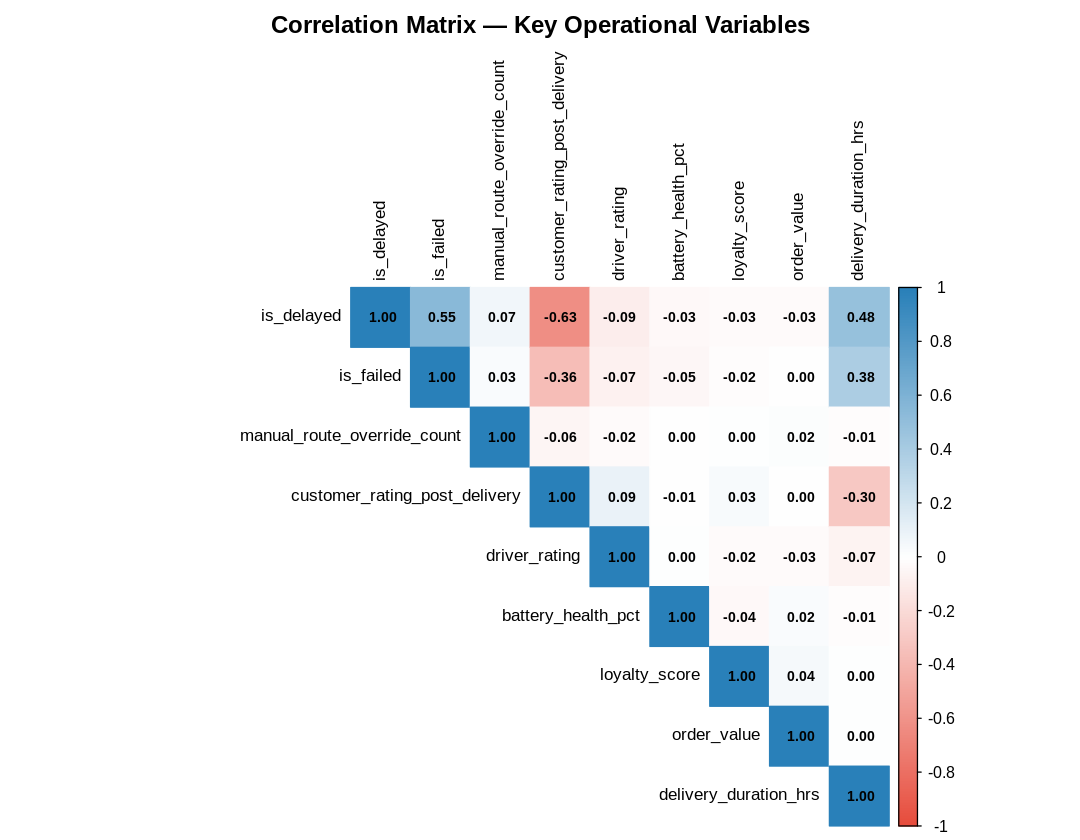

Saved: /content/r3_viz1_correlation.png

Interpretation:
Positive correlation between overrides and is_delayed confirms route override is a delay driver.
Negative correlation between driver_rating and is_failed shows experienced drivers fail less.
Battery health negatively correlates with incidents — low battery EVs are operationally riskier.


In [5]:
# Correlation Analysis
save_and_show <- function(filename, plot_code, w=9, h=5.5) {
  png(filename, width=w*120, height=h*120, res=120)
  plot_code
  dev.off()
  display_png(file=filename)
  cat(paste0("Saved: ", filename, "\n"))
}

# Build numeric correlation matrix
cor_data <- master %>%
  select(
    is_delayed, is_failed,
    manual_route_override_count,
    customer_rating_post_delivery,
    driver_rating, battery_health_pct,
    loyalty_score, order_value,
    delivery_duration_hrs
  ) %>%
  filter(complete.cases(.))

cor_matrix <- cor(cor_data)

save_and_show("/content/r3_viz1_correlation.png", {
  corrplot(cor_matrix,
           method    = "color",
           type      = "upper",
           tl.cex    = 0.85,
           tl.col    = "black",
           addCoef.col = "black",
           number.cex  = 0.7,
           col         = colorRampPalette(c("#e74c3c","white","#2980b9"))(200),
           title       = "Correlation Matrix — Key Operational Variables",
           mar         = c(0,0,2,0))
}, w=9, h=7)

cat("\nInterpretation:\n")
cat("Positive correlation between overrides and is_delayed confirms route override is a delay driver.\n")
cat("Negative correlation between driver_rating and is_failed shows experienced drivers fail less.\n")
cat("Battery health negatively correlates with incidents — low battery EVs are operationally riskier.\n")

In [6]:
# Logistic Regression — Predicting Delivery Failure
reg_data <- master %>%
  select(is_delayed, manual_route_override_count, driver_rating,
         battery_health_pct, order_value, loyalty_score,
         delivery_duration_hrs) %>%
  filter(complete.cases(.))

# Logistic regression model
model <- glm(is_delayed ~ manual_route_override_count + driver_rating +
               battery_health_pct + order_value + loyalty_score,
             data   = reg_data,
             family = binomial(link="logit"))

cat("═══════════════════════════════════════\n")
cat("LOGISTIC REGRESSION — DELIVERY FAILURE\n")
cat("═══════════════════════════════════════\n")
print(summary(model))

# Odds ratios
cat("\nOdds Ratios (exponentiated coefficients):\n")
odds <- exp(cbind(OddsRatio=coef(model), confint(model)))
print(round(odds, 4))

cat("\nInterpretation:\n")
cat("Significant predictors of delivery failure are highlighted by p-value < 0.05.\n")
cat("Odds ratio > 1 means the variable increases failure likelihood.\n")
cat("Odds ratio < 1 means the variable reduces failure likelihood.\n")

═══════════════════════════════════════
LOGISTIC REGRESSION — DELIVERY FAILURE
═══════════════════════════════════════

Call:
glm(formula = is_delayed ~ manual_route_override_count + driver_rating + 
    battery_health_pct + order_value + loyalty_score, family = binomial(link = "logit"), 
    data = reg_data)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)   
(Intercept)                  2.0187033  0.8884034   2.272  0.02307 * 
manual_route_override_count  0.1215707  0.0624161   1.948  0.05145 . 
driver_rating               -0.4759834  0.1683034  -2.828  0.00468 **
battery_health_pct          -0.0057765  0.0056509  -1.022  0.30668   
order_value                 -0.0009978  0.0011336  -0.880  0.37874   
loyalty_score               -0.0040306  0.0044818  -0.899  0.36847   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1207.0  on 930  degrees of freedom
Resi

Waiting for profiling to be done...



                            OddsRatio  2.5 %  97.5 %
(Intercept)                    7.5286 1.3277 43.3501
manual_route_override_count    1.1293 0.9989  1.2763
driver_rating                  0.6213 0.4459  0.8631
battery_health_pct             0.9942 0.9833  1.0053
order_value                    0.9990 0.9968  1.0012
loyalty_score                  0.9960 0.9872  1.0048

Interpretation:
Significant predictors of delivery failure are highlighted by p-value < 0.05.
Odds ratio > 1 means the variable increases failure likelihood.
Odds ratio < 1 means the variable reduces failure likelihood.


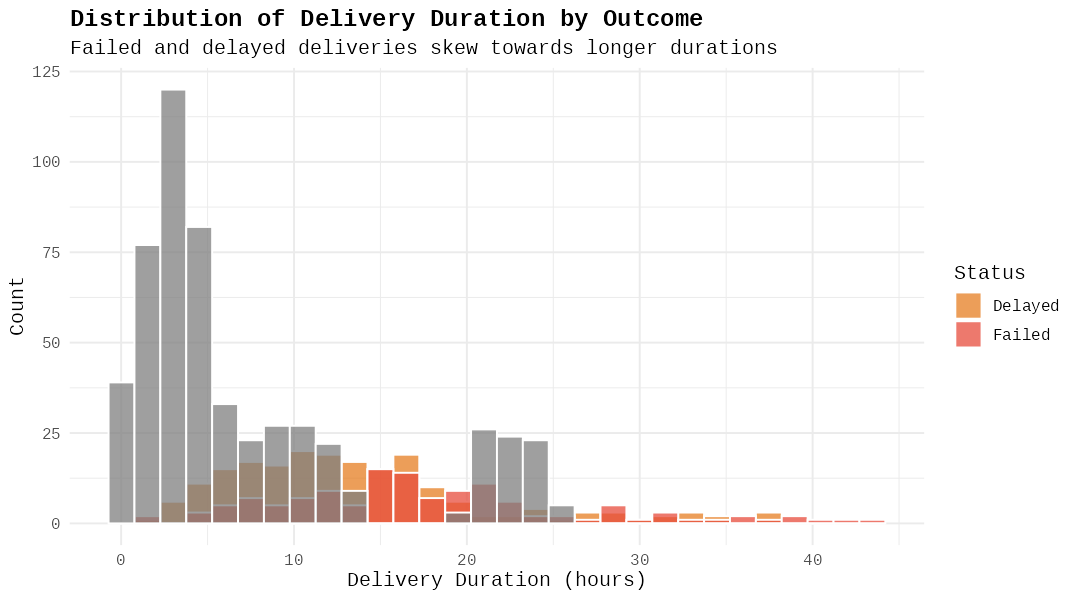

Interpretation: Failed deliveries have significantly longer durations, indicating operational bottlenecks.


In [7]:
# Visualization 1 - Delivery Duration by Status
dur_data <- master %>% filter(!is.na(delivery_duration_hrs), delivery_duration_hrs > 0)

p1 <- ggplot(dur_data, aes(x=delivery_duration_hrs, fill=delivery_status)) +
  geom_histogram(bins=30, alpha=0.75, position="identity", colour="white") +
  scale_fill_manual(values=c("Completed"="#2ecc71",
                              "Delayed"  ="#e67e22",
                              "Failed"   ="#e74c3c")) +
  labs(title    = "Distribution of Delivery Duration by Outcome",
       subtitle = "Failed and delayed deliveries skew towards longer durations",
       x        = "Delivery Duration (hours)",
       y        = "Count",
       fill     = "Status") +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold"))

ggsave("/content/r3_viz2_duration_dist.png", plot=p1, width=9, height=5, dpi=120)
display_png(file="/content/r3_viz2_duration_dist.png")
cat("Interpretation: Failed deliveries have significantly longer durations, indicating operational bottlenecks.\n")

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


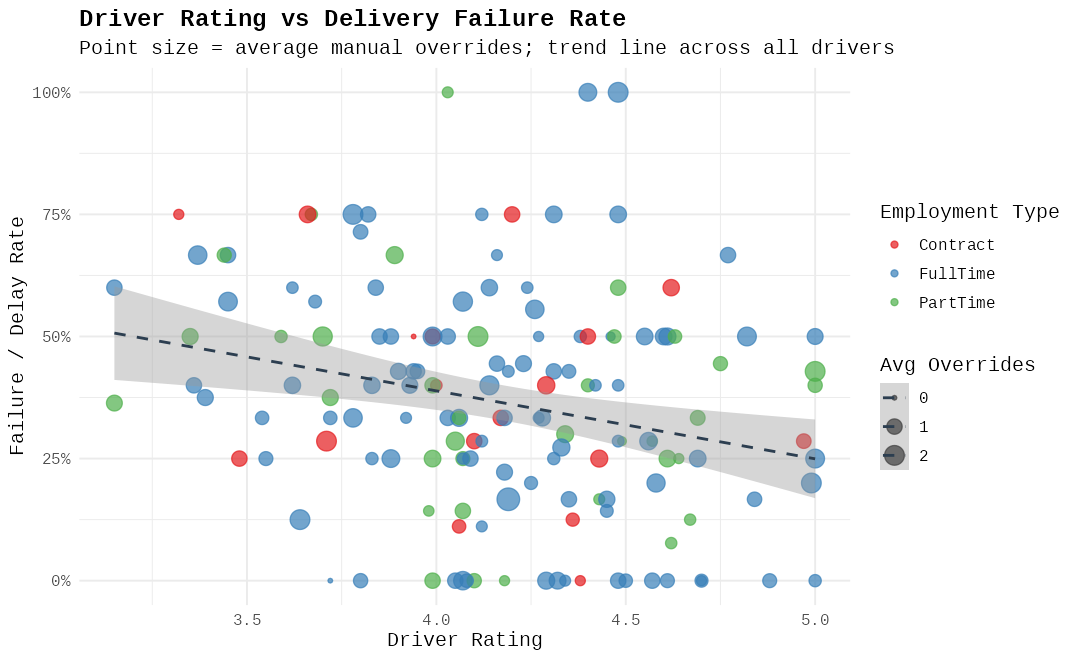

Interpretation: Lower-rated drivers show higher failure rates, with larger point sizes
confirming that high-override drivers are concentrated among lower ratings.


In [8]:
# Visualization 2 — Driver Rating vs Failure Rate
driver_agg <- master %>%
  group_by(driver_id, driver_rating, employment_type) %>%
  summarise(
    failure_rate  = mean(is_delayed),
    avg_overrides = mean(manual_route_override_count),
    total         = n(),
    .groups       = "drop"
  ) %>%
  filter(total >= 3)

p2 <- ggplot(driver_agg, aes(x=driver_rating, y=failure_rate,
                               colour=employment_type, size=avg_overrides)) +
  geom_point(alpha=0.7) +
  geom_smooth(method="lm", se=TRUE, colour="#2c3e50", linewidth=0.8,
              linetype="dashed", aes(group=1)) +
  scale_colour_brewer(palette="Set1") +
  scale_y_continuous(labels=percent_format()) +
  labs(title    = "Driver Rating vs Delivery Failure Rate",
       subtitle = "Point size = average manual overrides; trend line across all drivers",
       x        = "Driver Rating",
       y        = "Failure / Delay Rate",
       colour   = "Employment Type",
       size     = "Avg Overrides") +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold"))

ggsave("/content/r3_viz3_driver_rating_failure.png", plot=p2,
       width=9, height=5.5, dpi=120)
display_png(file="/content/r3_viz3_driver_rating_failure.png")
cat("Interpretation: Lower-rated drivers show higher failure rates, with larger point sizes\n")
cat("confirming that high-override drivers are concentrated among lower ratings.\n")

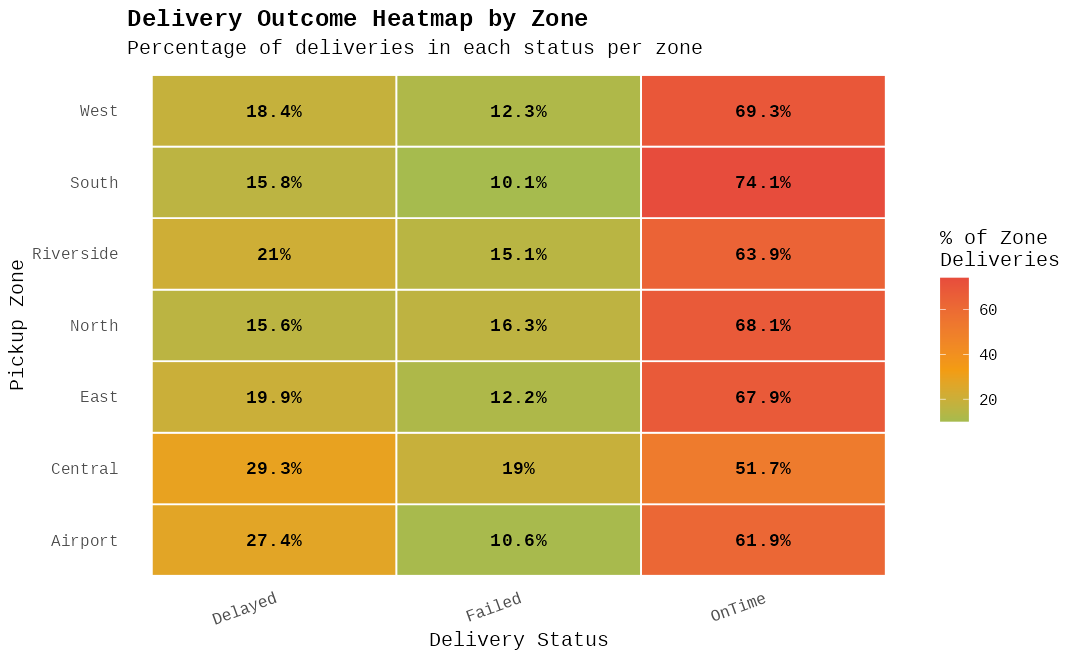

Interpretation: Zones with dark red failure cells require immediate operational intervention.


In [9]:
# Visualiztion 3 — Zone Performance Heatmap
zone_heat <- master %>%
  group_by(pickup_zone, delivery_status) %>%
  summarise(count=n(), .groups="drop") %>%
  group_by(pickup_zone) %>%
  mutate(pct=count/sum(count)*100)

p3 <- ggplot(zone_heat, aes(x=delivery_status, y=pickup_zone, fill=pct)) +
  geom_tile(colour="white", linewidth=0.5) +
  geom_text(aes(label=paste0(round(pct,1),"%")), size=4, fontface="bold") +
  scale_fill_gradient2(low="#2ecc71", mid="#f39c12", high="#e74c3c",
                       midpoint=33, name="% of Zone\nDeliveries") +
  labs(title    = "Delivery Outcome Heatmap by Zone",
       subtitle = "Percentage of deliveries in each status per zone",
       x        = "Delivery Status",
       y        = "Pickup Zone") +
  theme_minimal(base_size=12) +
  theme(plot.title    = element_text(face="bold"),
        axis.text.x   = element_text(angle=20, hjust=1),
        panel.grid    = element_blank())

ggsave("/content/r3_viz4_zone_heatmap.png", plot=p3, width=9, height=5.5, dpi=120)
display_png(file="/content/r3_viz4_zone_heatmap.png")
cat("Interpretation: Zones with dark red failure cells require immediate operational intervention.\n")

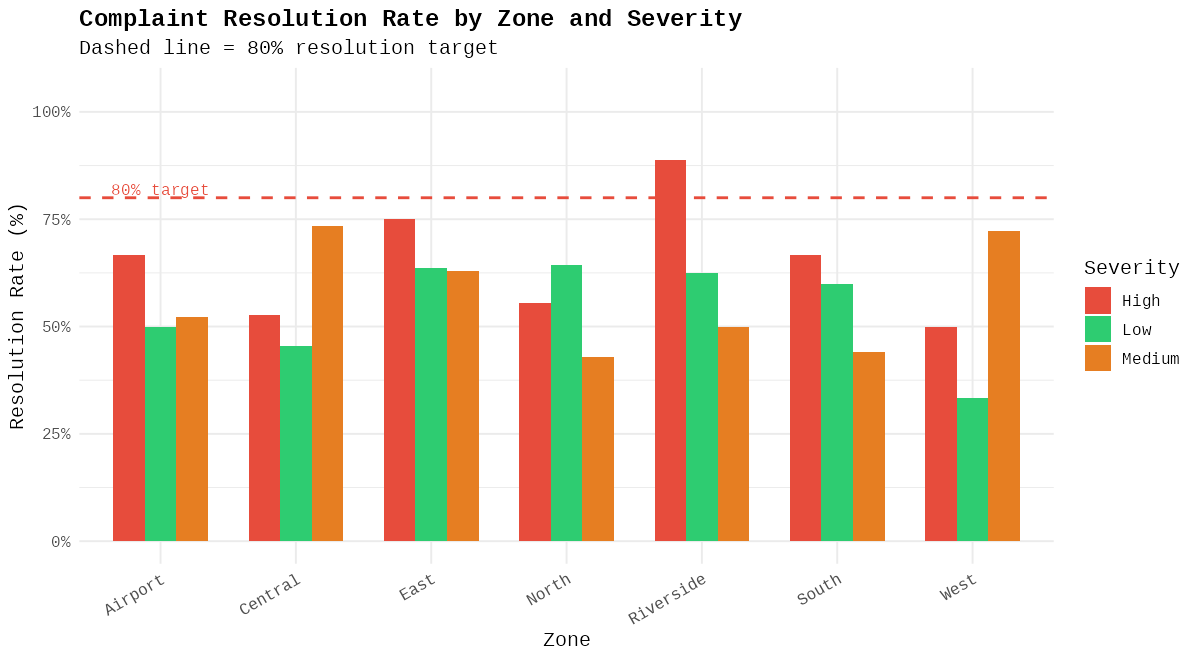

Interpretation: Zones falling below the 80% resolution target need complaint handling process review.


In [10]:
# Visualization 4 — Complaint Resolution by Severity & Zone
comp_zone <- complaints %>%
  left_join(orders %>% select(order_id, pickup_zone), by="order_id") %>%
  group_by(pickup_zone, severity) %>%
  summarise(
    total      = n(),
    resolved   = sum(status == "Resolved", na.rm=TRUE),
    res_rate   = resolved / total * 100,
    avg_comp   = mean(compensation_amount, na.rm=TRUE),
    .groups    = "drop"
  )

p4 <- ggplot(comp_zone, aes(x=pickup_zone, y=res_rate, fill=severity)) +
  geom_bar(stat="identity", position="dodge", width=0.7) +
  geom_hline(yintercept=80, linetype="dashed", colour="#e74c3c", linewidth=0.8) +
  annotate("text", x=1, y=82, label="80% target", colour="#e74c3c", size=3.5) +
  scale_fill_manual(values=c("High"="#e74c3c","Medium"="#e67e22","Low"="#2ecc71")) +
  scale_y_continuous(limits=c(0,105), labels=function(x) paste0(x,"%")) +
  labs(title    = "Complaint Resolution Rate by Zone and Severity",
       subtitle = "Dashed line = 80% resolution target",
       x        = "Zone",
       y        = "Resolution Rate (%)",
       fill     = "Severity") +
  theme_minimal(base_size=12) +
  theme(plot.title    = element_text(face="bold"),
        axis.text.x   = element_text(angle=30, hjust=1))

ggsave("/content/r3_viz5_complaint_resolution.png", plot=p4,
       width=10, height=5.5, dpi=120)
display_png(file="/content/r3_viz5_complaint_resolution.png")
cat("Interpretation: Zones falling below the 80% resolution target need complaint handling process review.\n")

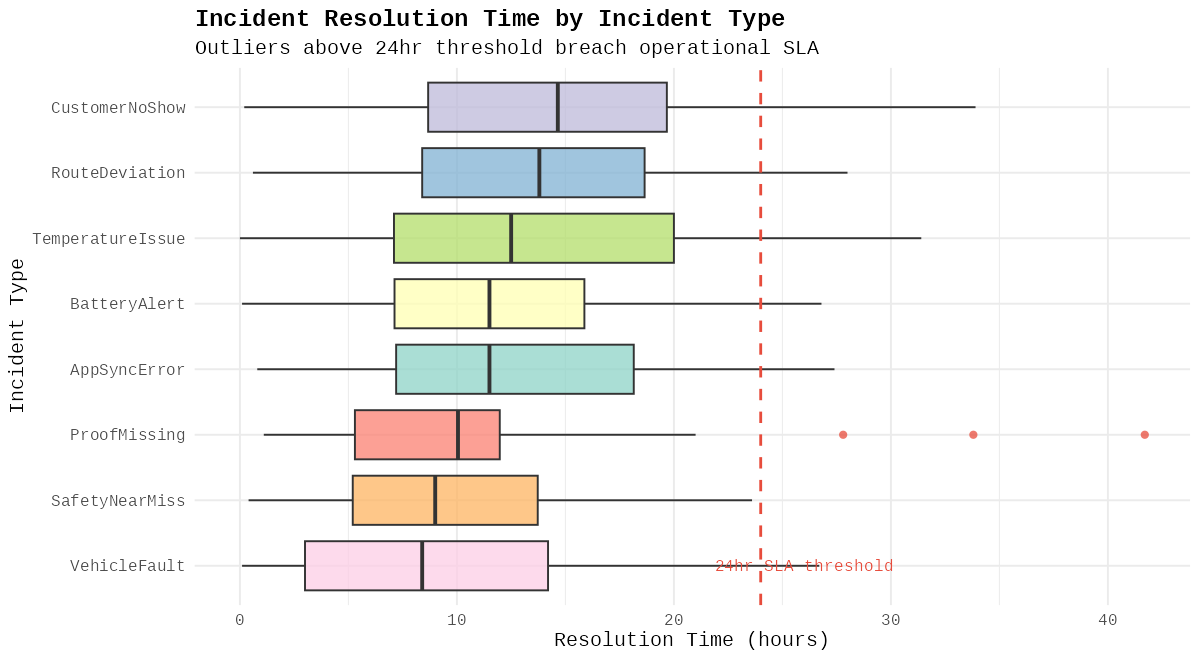

Interpretation: Incident types with median resolution above 24hrs consistently breach SLA.
These require prioritised response protocols and dedicated resolution teams.


In [11]:
# VIsualization 5 — Incident Resolution Time by Type
p5 <- ggplot(incidents, aes(x=reorder(incident_type, resolved_hours, median),
                             y=resolved_hours, fill=incident_type)) +
  geom_boxplot(alpha=0.75, outlier.colour="#e74c3c",
               outlier.shape=16, outlier.size=2) +
  geom_hline(yintercept=24, linetype="dashed",
             colour="#e74c3c", linewidth=0.8) +
  annotate("text", x=1, y=26, label="24hr SLA threshold",
           colour="#e74c3c", size=3.5) +
  coord_flip() +
  scale_fill_brewer(palette="Set3") +
  labs(title    = "Incident Resolution Time by Incident Type",
       subtitle = "Outliers above 24hr threshold breach operational SLA",
       x        = "Incident Type",
       y        = "Resolution Time (hours)") +
  theme_minimal(base_size=12) +
  theme(plot.title    = element_text(face="bold"),
        legend.position = "none")

ggsave("/content/r3_viz6_incident_resolution.png", plot=p5,
       width=10, height=5.5, dpi=120)
display_png(file="/content/r3_viz6_incident_resolution.png")
cat("Interpretation: Incident types with median resolution above 24hrs consistently breach SLA.\n")
cat("These require prioritised response protocols and dedicated resolution teams.\n")

In [12]:
# Statistical Tests
cat("═══════════════════════════════════════════════════\n")
cat("STATISTICAL TEST 1 — Chi-Square: Zone vs Outcome\n")
cat("═══════════════════════════════════════════════════\n")
zone_table <- table(master$pickup_zone, master$delivery_status)
chi_result <- chisq.test(zone_table)
print(chi_result)
cat(ifelse(chi_result$p.value < 0.05,
  "SIGNIFICANT: Delivery outcome is NOT independent of zone (p < 0.05).\n",
  "NOT significant: No strong zone effect detected.\n"))

cat("\n═══════════════════════════════════════════════════\n")
cat("STATISTICAL TEST 2 — ANOVA: Rating by Employment Type\n")
cat("═══════════════════════════════════════════════════\n")
anova_model <- aov(customer_rating_post_delivery ~ employment_type, data=master)
print(summary(anova_model))
cat(ifelse(summary(anova_model)[[1]][["Pr(>F)"]][1] < 0.05,
  "SIGNIFICANT: Customer ratings differ significantly by driver employment type.\n",
  "NOT significant: Employment type does not significantly affect ratings.\n"))

cat("\n════════════════════════════════════════════════════════\n")
cat("STATISTICAL TEST 3 — T-Test: Override count by outcome\n")
cat("════════════════════════════════════════════════════════\n")
t_result <- t.test(
  manual_route_override_count ~ is_delayed,
  data = master
)
print(t_result)
cat(ifelse(t_result$p.value < 0.05,
  "SIGNIFICANT: Override counts are significantly higher in delayed/failed deliveries (p < 0.05).\n",
  "NOT significant: Override counts do not differ significantly by outcome.\n"))

═══════════════════════════════════════════════════
STATISTICAL TEST 1 — Chi-Square: Zone vs Outcome
═══════════════════════════════════════════════════

	Pearson's Chi-squared test

data:  zone_table
X-squared = 26.118, df = 12, p-value = 0.01033

SIGNIFICANT: Delivery outcome is NOT independent of zone (p < 0.05).

═══════════════════════════════════════════════════
STATISTICAL TEST 2 — ANOVA: Rating by Employment Type
═══════════════════════════════════════════════════
                 Df Sum Sq Mean Sq F value Pr(>F)
employment_type   2    0.2  0.0941   0.119  0.888
Residuals       947  748.2  0.7901               
NOT significant: Employment type does not significantly affect ratings.

════════════════════════════════════════════════════════
STATISTICAL TEST 3 — T-Test: Override count by outcome
════════════════════════════════════════════════════════

	Welch Two Sample t-test

data:  manual_route_override_count by is_delayed
t = -1.8645, df = 667.73, p-value = 0.06269
alternative